In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('placement.csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


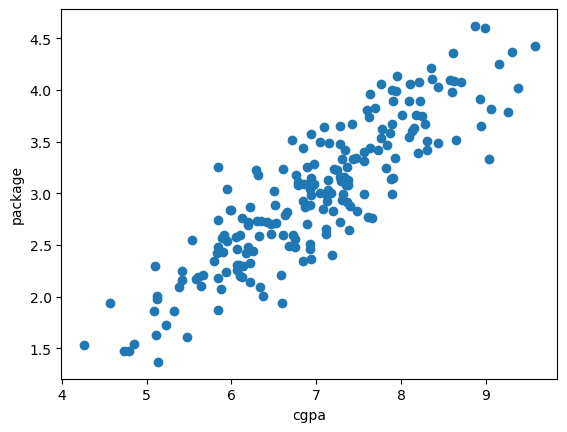

In [27]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('cgpa')
plt.ylabel('package')
plt.show()

In [16]:
X=df.iloc[:,0].values.reshape(-1,1)
y=df.iloc[:,-1].values.reshape(-1,1)
X

array([[6.89],
       [5.12],
       [7.82],
       [7.42],
       [6.94],
       [7.89],
       [6.73],
       [6.75],
       [6.09],
       [8.31],
       [5.32],
       [6.61],
       [8.94],
       [6.93],
       [7.73],
       [7.25],
       [6.84],
       [5.38],
       [6.94],
       [7.48],
       [7.28],
       [6.85],
       [6.14],
       [6.19],
       [6.53],
       [7.28],
       [8.31],
       [5.42],
       [5.94],
       [7.15],
       [7.36],
       [8.1 ],
       [6.96],
       [6.35],
       [7.34],
       [6.87],
       [5.99],
       [5.9 ],
       [8.62],
       [7.43],
       [9.38],
       [6.89],
       [5.95],
       [7.66],
       [5.09],
       [7.87],
       [6.07],
       [5.84],
       [8.63],
       [8.87],
       [9.58],
       [9.26],
       [8.37],
       [6.47],
       [6.86],
       [8.2 ],
       [5.84],
       [6.6 ],
       [6.92],
       [7.56],
       [5.61],
       [5.48],
       [6.34],
       [9.16],
       [7.36],
       [7.6 ],
       [5.

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)


In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
lr=LinearRegression()


In [20]:
lr.fit(X_train,y_train)
y_predict=lr.predict(X_test)

In [24]:
from sklearn.metrics import r2_score,mean_squared_error
print(r2_score(y_test,y_predict))
np.sqrt(mean_squared_error(y_test,y_predict))


0.7297167943957027


np.float64(0.31970503685951224)

In [30]:
m=lr.coef_

In [31]:
b=lr.intercept_

In [32]:
m*8.58+b

array([[3.91530795]])

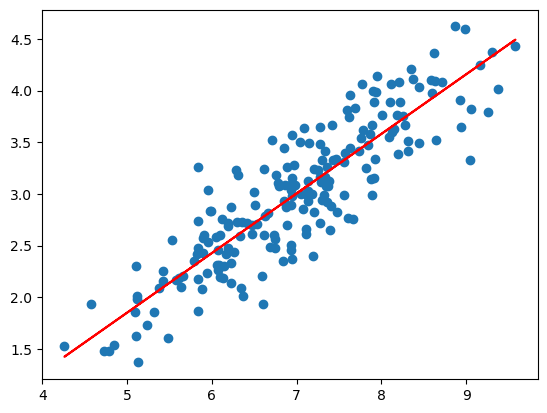

In [36]:
# how data is scattered and how my model predicted based on my trained data
plt.scatter(X,y)
plt.plot(X_train,lr.predict(X_train),color='red')


# Creating my own Linear Regression class using OLS method

In [ ]:
class LinearRegressionScratch:
    def __init__(self):
        self.b=0
        self.m=0
    def fit(self,X,y):
        num=0
        den=0
        X_avg=np.mean(X)
        y_avg=np.mean(y)
        for i in range(len(X)):
            num+=(X[i]-X_avg)*(y[i]-y_avg)
            den+=(X[i]-X_avg)**2
        self.m=num/den
        self.b=y_avg-self.m*X_avg
    def predict(self,X):
        return self.m*X+self.b

    

In [40]:
lr=LinearRegressionScratch()

In [41]:
lr.fit(X_train,y_train)

In [43]:
lr.predict(X_test)

array([[2.97012606],
       [2.55516816],
       [2.61856451],
       [3.40237388],
       [3.05657563],
       [2.35921582],
       [3.51763996],
       [2.4687186 ],
       [4.1227869 ],
       [3.21794814],
       [2.12868365],
       [3.19489493],
       [2.53787825],
       [3.05081232],
       [3.36779405],
       [2.86062328],
       [2.63009112],
       [2.82028015],
       [2.37074243],
       [2.91825632],
       [3.1660784 ],
       [2.3361626 ],
       [3.50611335],
       [3.9902309 ],
       [2.20360661],
       [1.90967809],
       [3.08539215],
       [2.6070379 ],
       [1.9212047 ],
       [1.90391479],
       [2.91249302],
       [3.69630239],
       [2.60127459],
       [2.09410383],
       [2.50906173],
       [3.64443265],
       [3.17184171],
       [2.97012606],
       [3.83462169],
       [2.50329842]])

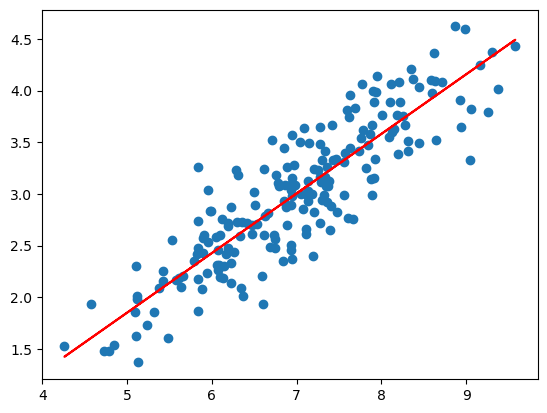

In [44]:
plt.scatter(X,y)
plt.plot(X_train,lr.predict(X_train),color='red')

# we will calculate mse,mae,r2score and adjusted r2score    

In [45]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [ ]:
# 1. Error on your test data (Unseen data performance)
print("***Test Error****")
print("mean_absolute_error (Test):", mean_absolute_error(y_test, y_predict))
print("mean_squared_error (Test):", mean_squared_error(y_test, y_predict))
print("r2_score (Test):", r2_score(y_test, y_predict))


# 2. Error on your training data (What you asked about)
print("***Train Error****")
print("mean_absolute_error (Train):", mean_absolute_error(y_train, lr.predict(X_train)))
print("mean_squared_error (Train):", mean_squared_error(y_train, lr.predict(X_train)))
print("r2_score (Train):", r2_score(y_train, lr.predict(X_train)))







***Test Error****
mean_absolute_error (Test): 0.2552433448620408
mean_squared_error (Test): 0.10221131059334207
r2_score (Test): 0.7297167943957027
***Train Error****
mean_absolute_error (Train): 0.2604859101447728
mean_squared_error (Train): 0.10802534053387007
r2_score (Train): 0.7813227298629095


In [59]:
def calculate_adjusted_r2score(r2score,X):
    n=X.shape[0] # no of rows
    k=X.shape[1] # no of features
    adjusted_r2score=1-(1-r2score)*(n-1)/(n-k-1)
    return adjusted_r2score


In [60]:
X_test.shape


(40, 1)

# if we add irrelavent feature to the model then adjusted r2 score of test data will decrease but adjusted r2 score of train data will increase or stay same because it is based on how my model learned that feature

In [61]:
print("Adjusted R2 score on test data:",calculate_adjusted_r2score(r2_score(y_test,y_predict),X_test))
print("Adjusted R2 score on train data:",calculate_adjusted_r2score(r2_score(y_train,lr.predict(X_train)),X_train))

Adjusted R2 score on test data: 0.7226040784587475
Adjusted R2 score on train data: 0.7799386965076115


# overfitting hapens when my training r2 score or adjusted r2 score is significantly higher than my test r2 score or adjusted r2 score

# underfitting happens when my training r2 score or adjusted r2 score is significantly lower than my test r2 score or adjusted r2 score